# حل مشروع Modul 2 : Ekualisasi dan Spesifikasi
سيتم استخدام هذا الملف بصيغة Python Interactive (تفاعلي)، حيث تم تقسيم الكود باستخدام `# %%` ليتصرف تماماً كخلايا Jupyter Notebook في محرر VS Code.

In [1]:
# استيراد المكتبات الأساسية
# نستورد مكتبة numpy للتعامل مع المصفوفات، matplotlib للرسم، و cv2 لقراءة الصور فقط
import numpy as np
import matplotlib.pyplot as plt
import cv2

# قراءة الصور المطلوبة وتحويلها من BGR إلى RGB باستخدام تقطيع المصفوفات
# 1. الصورة الأساسية (Windut)
windut_img = cv2.imread('Assets/Windut.png')
windut_rgb = windut_img[:, :, ::-1]

# 2. صورة الزهرة السوداء (Bunga Ireng) كصورة مرجعية
bunga_img = cv2.imread('Assets/Bunga.png')
bunga_rgb = bunga_img[:, :, ::-1]

# 3. صورة الخلفية (Langit)
langit_img = cv2.imread('Assets/Langit.png')
langit_rgb = langit_img[:, :, ::-1]

**الخطوة 1: استيراد المكتبات وتحميل الصور**
قمنا باستيراد المكتبات الأساسية وقراءة الصور باستخدام cv2.imread. تم عكس القنوات من BGR إلى RGB باستخدام Slicing [::-1] لعرض الألوان بشكل صحيح. 
*(تم وضع هذا النص تحت خلية الكود لأنه لا يوجد مخرج صورة هنا).*

**الخطوة 2: تقطيع الصورة وإعادة بنائها (Slicing and Reconstructing)**
سنقوم بتقطيع الصورة الأساسية إلى 4 أرباع متساوية باستخدام Slicing، ثم عرض هذه الأجزاء، وأخيراً إعادة بناء الصورة في مصفوفة فارغة وعرض الصورة المجمعة.
*(تم وضع هذا النص فوق الكود لوجود مخرجات صور).*

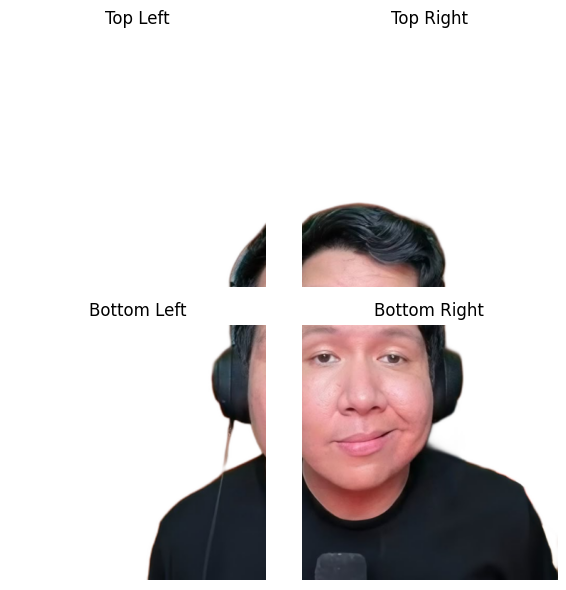

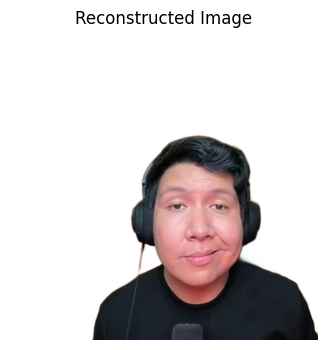

In [2]:
# حساب أبعاد الصورة لإيجاد نقطة المنتصف
h, w, c = windut_rgb.shape
mid_h, mid_w = h // 2, w // 2

# تقسيم الصورة إلى 4 أرباع باستخدام Slicing
q1 = windut_rgb[:mid_h, :mid_w]       # الربع العلوي الأيسر
q2 = windut_rgb[:mid_h, mid_w:]       # الربع العلوي الأيمن
q3 = windut_rgb[mid_h:, :mid_w]       # الربع السفلي الأيسر
q4 = windut_rgb[mid_h:, mid_w:]       # الربع السفلي الأيمن

# عرض الأجزاء الأربعة
fig, axs = plt.subplots(2, 2, figsize=(6, 6))
axs[0, 0].imshow(q1)
axs[0, 0].set_title("Top Left")
axs[0, 1].imshow(q2)
axs[0, 1].set_title("Top Right")
axs[1, 0].imshow(q3)
axs[1, 0].set_title("Bottom Left")
axs[1, 1].imshow(q4)
axs[1, 1].set_title("Bottom Right")
for ax in axs.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

# إعادة بناء الصورة باستخدام np.zeros
reconstructed = np.zeros((h, w, c), dtype=np.uint8)
reconstructed[:mid_h, :mid_w] = q1
reconstructed[:mid_h, mid_w:] = q2
reconstructed[mid_h:, :mid_w] = q3
reconstructed[mid_h:, mid_w:] = q4

# عرض الصورة المُعاد بناؤها
plt.figure(figsize=(4, 4))
plt.imshow(reconstructed)
plt.title("Reconstructed Image")
plt.axis('off')
plt.show()

**الخطوة 3: التحويل للرمادي وتسوية المدرج التكراري (Manual Histogram Equalization)**
نحول الصورة لرمادي ثم نحسب التكرار (Histogram) والتوزيع التراكمي (CDF) يدوياً. ثم نبني خريطة التحويل باستخدام np.round() فقط لتسوية الإضاءة ونعرض الرسوم البيانية.

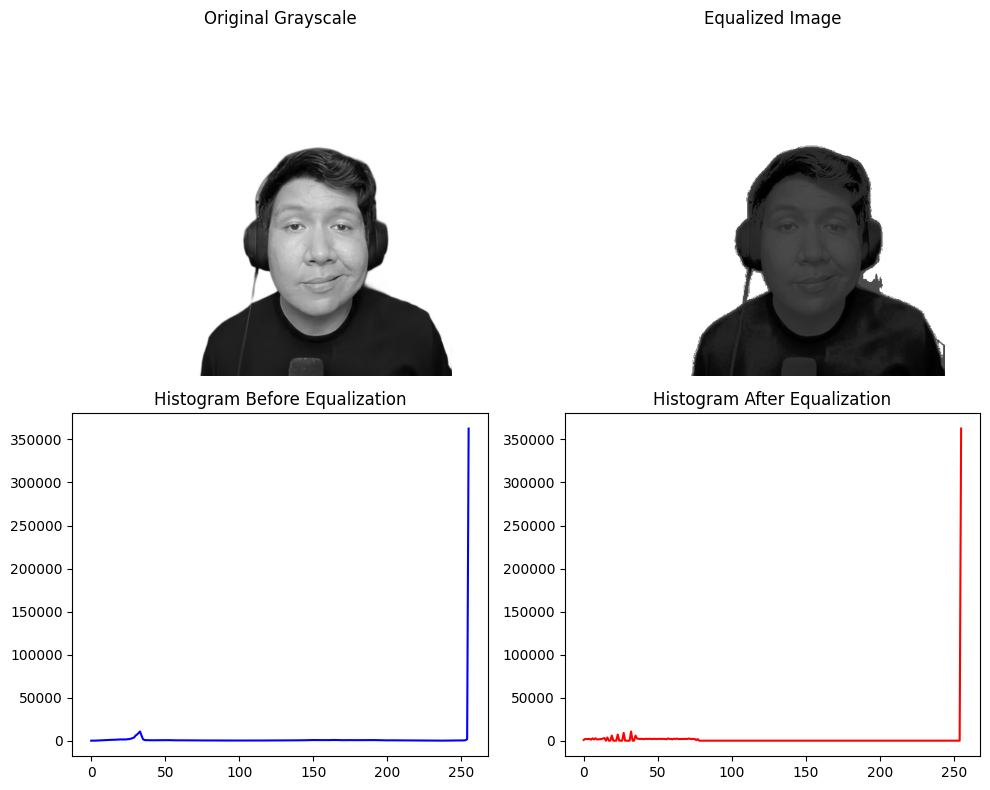

In [3]:
# تحويل الصورة إلى الأبيض والأسود (Grayscale) باستخدام cv2 كاستثناء مسموح
windut_gray = cv2.cvtColor(windut_img, cv2.COLOR_BGR2GRAY)

# دوال يدوية لحساب الـ Histogram والـ CDF (بدون دوال مساعدة)
def get_manual_histogram(image):
    hist = [0] * 256
    rows, cols = image.shape
    for i in range(rows):
        for j in range(cols):
            val = image[i, j]
            hist[val] += 1
    return hist

def get_manual_cdf(hist):
    cdf = [0] * 256
    total = 0
    for i in range(256):
        total += hist[i]
        cdf[i] = total
    return cdf

# حساب البيانات للصورة الأصلية
hist_original = get_manual_histogram(windut_gray)
cdf_original = get_manual_cdf(hist_original)

# إنشاء مصفوفة التحويل (Mapping)
total_pixels = windut_gray.shape[0] * windut_gray.shape[1]
mapping_eq = [0] * 256
for i in range(256):
    mapping_eq[i] = int(np.round((cdf_original[i] / total_pixels) * 255))

# تطبيق خريطة التحويل
windut_equalized = np.zeros((windut_gray.shape[0], windut_gray.shape[1]), dtype=np.uint8)
for i in range(windut_gray.shape[0]):
    for j in range(windut_gray.shape[1]):
        windut_equalized[i, j] = mapping_eq[windut_gray[i, j]]

hist_equalized = get_manual_histogram(windut_equalized)

# عرض الصور والرسوم البيانية
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].imshow(windut_gray, cmap='gray')
axs[0, 0].set_title("Original Grayscale")
axs[0, 0].axis('off')

axs[0, 1].imshow(windut_equalized, cmap='gray')
axs[0, 1].set_title("Equalized Image")
axs[0, 1].axis('off')

axs[1, 0].plot(hist_original, color='blue')
axs[1, 0].set_title("Histogram Before Equalization")

axs[1, 1].plot(hist_equalized, color='red')
axs[1, 1].set_title("Histogram After Equalization")

plt.tight_layout()
plt.show()

**الخطوة 4: مطابقة المدرج التكراري (Manual Histogram Specification)**
تعديل صورة Windut الرمادية لتتطابق مع الصورة المرجعية Bunga Ireng بحساب الـ CDF لكليهما وإيجاد الأقرب يدوياً.

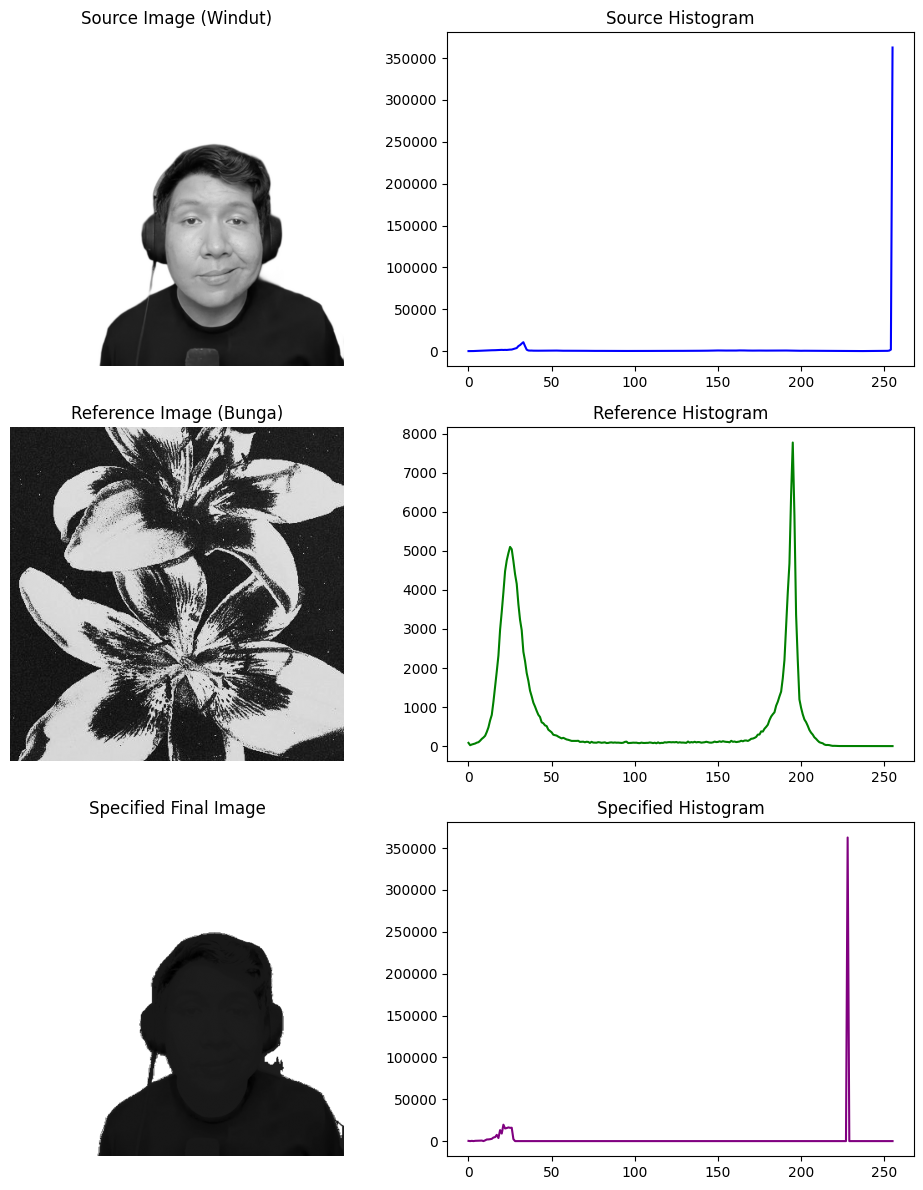

In [4]:
bunga_gray = cv2.cvtColor(bunga_img, cv2.COLOR_BGR2GRAY)
hist_ref = get_manual_histogram(bunga_gray)
cdf_ref = get_manual_cdf(hist_ref)

total_pixels_ref = bunga_gray.shape[0] * bunga_gray.shape[1]

# تحويل لقيم احتمالية للمقارنة
cdf_norm_original = [c / total_pixels for c in cdf_original]
cdf_norm_ref = [c / total_pixels_ref for c in cdf_ref]

# بناء مصفوفة المطابقة
mapping_spec = [0] * 256
for i in range(256):
    min_diff = abs(cdf_norm_original[i] - cdf_norm_ref[0])
    best_match = 0
    for j in range(1, 256):
        diff = abs(cdf_norm_original[i] - cdf_norm_ref[j])
        if diff < min_diff:
            min_diff = diff
            best_match = j
    mapping_spec[i] = best_match

windut_specified = np.zeros((windut_gray.shape[0], windut_gray.shape[1]), dtype=np.uint8)
for i in range(windut_gray.shape[0]):
    for j in range(windut_gray.shape[1]):
        windut_specified[i, j] = mapping_spec[windut_gray[i, j]]

hist_specified = get_manual_histogram(windut_specified)

# عرض النتائج
fig, axs = plt.subplots(3, 2, figsize=(10, 12))

axs[0, 0].imshow(windut_gray, cmap='gray')
axs[0, 0].set_title("Source Image (Windut)")
axs[0, 1].plot(hist_original, color='blue')
axs[0, 1].set_title("Source Histogram")

axs[1, 0].imshow(bunga_gray, cmap='gray')
axs[1, 0].set_title("Reference Image (Bunga)")
axs[1, 1].plot(hist_ref, color='green')
axs[1, 1].set_title("Reference Histogram")

axs[2, 0].imshow(windut_specified, cmap='gray')
axs[2, 0].set_title("Specified Final Image")
axs[2, 1].plot(hist_specified, color='purple')
axs[2, 1].set_title("Specified Histogram")

for ax in axs[:, 0]:
    ax.axis('off')

plt.tight_layout()
plt.show()

**الخطوة 5: القص، العزل، والدمج للصور الرمادية (Cropping, Masking, and Merging - Grayscale)**
سنقص الصورتين للحصول على نفس الحجم (min_h, min_w)، ثم نقوم بعزل كائن Windut ودمجه بالخلفية، وأخيراً عمل Specification أخير.

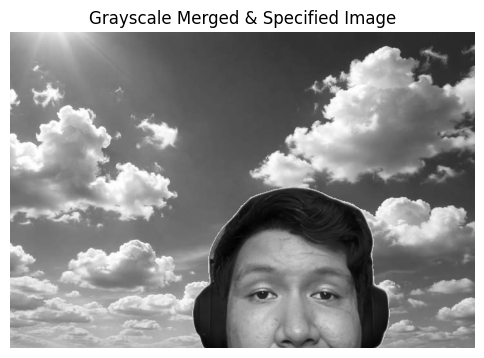

In [5]:
langit_gray = cv2.cvtColor(langit_img, cv2.COLOR_BGR2GRAY)

# إيجاد الأبعاد الأصغر للقص (بدون resize)
min_h = min(windut_gray.shape[0], langit_gray.shape[0])
min_w = min(windut_gray.shape[1], langit_gray.shape[1])

windut_crop_gray = windut_gray[:min_h, :min_w]
langit_crop_gray = langit_gray[:min_h, :min_w]

# عملية الدمج والعزل اليدوي
merged_gray = np.zeros((min_h, min_w), dtype=np.uint8)
for i in range(min_h):
    for j in range(min_w):
        # البكسل الأبيض الفاتح (فوق 240) نعتبره خلفية ونضع صورة السماء بداله
        if windut_crop_gray[i, j] > 240:
            merged_gray[i, j] = langit_crop_gray[i, j]
        else:
            merged_gray[i, j] = windut_crop_gray[i, j]

# Histogram Specification لمطابقة ألوان الكائن المدمج مع السماء بشكل أفضل
hist_merged = get_manual_histogram(merged_gray)
cdf_merged = get_manual_cdf(hist_merged)
total_merged = min_h * min_w
cdf_norm_merged = [c / total_merged for c in cdf_merged]

hist_langit = get_manual_histogram(langit_crop_gray)
cdf_langit = get_manual_cdf(hist_langit)
cdf_norm_langit = [c / total_merged for c in cdf_langit]

mapping_final_gray = [0] * 256
for i in range(256):
    min_diff = abs(cdf_norm_merged[i] - cdf_norm_langit[0])
    best_match = 0
    for j in range(1, 256):
        diff = abs(cdf_norm_merged[i] - cdf_norm_langit[j])
        if diff < min_diff:
            min_diff = diff
            best_match = j
    mapping_final_gray[i] = best_match

final_merged_gray = np.zeros((min_h, min_w), dtype=np.uint8)
for i in range(min_h):
    for j in range(min_w):
        final_merged_gray[i, j] = mapping_final_gray[merged_gray[i, j]]

plt.figure(figsize=(6, 6))
plt.imshow(final_merged_gray, cmap='gray')
plt.title("Grayscale Merged & Specified Image")
plt.axis('off')
plt.show()

**الخطوة 6: الدمج الملون النهائي (Windut Cipularang - Final Color Merge)**
نقوم بإجراء نفس عمليات القص والدمج ولكن مع الصور الملونة، باستخدام شرط للون الأبيض لكل القنوات.

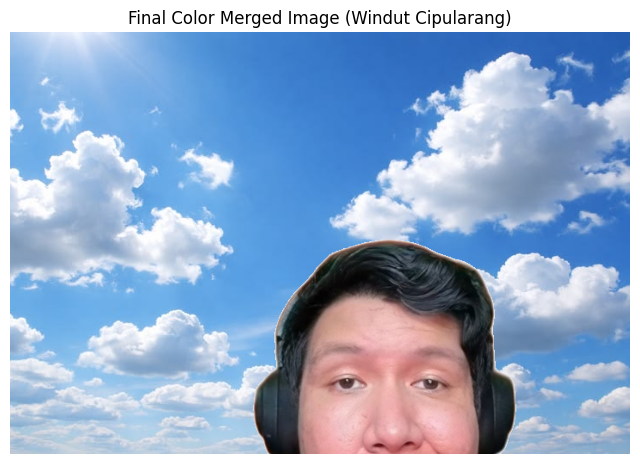

In [6]:
# القص للصور الملونة
windut_crop_color = windut_rgb[:min_h, :min_w]
langit_crop_color = langit_rgb[:min_h, :min_w]

final_color = np.zeros((min_h, min_w, 3), dtype=np.uint8)

for i in range(min_h):
    for j in range(min_w):
        r = windut_crop_color[i, j, 0]
        g = windut_crop_color[i, j, 1]
        b = windut_crop_color[i, j, 2]
        
        # التأكد أن البكسل أبيض كخلفية (قيم عالية بالقنوات الثلاثة)
        if r > 235 and g > 235 and b > 235:
            final_color[i, j, 0] = langit_crop_color[i, j, 0]
            final_color[i, j, 1] = langit_crop_color[i, j, 1]
            final_color[i, j, 2] = langit_crop_color[i, j, 2]
        else:
            final_color[i, j, 0] = r
            final_color[i, j, 1] = g
            final_color[i, j, 2] = b

plt.figure(figsize=(8, 8))
plt.imshow(final_color)
plt.title("Final Color Merged Image (Windut Cipularang)")
plt.axis('off')
plt.show()